Develop a Single-Layer Perceptron (SLP) for binary classification and compare its performance with a Multi-Layer Perceptron (MLP) using the same dataset

In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [29]:
# 1. Load Iris dataset
iris = load_iris()
print(iris.feature_names)
# Use only Setosa and Versicolor
X = iris.data[:100, [2, 3]]
y = iris.target[:100]
features_used = [iris.feature_names[i] for i in [2, 3]]

print("Features used:")
print(features_used)
print("Dataset shape:", X.shape)
print("Classes:", np.unique(y))

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Features used:
['petal length (cm)', 'petal width (cm)']
Dataset shape: (100, 2)
Classes: [0 1]


In [30]:
# 2. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
# 3. Standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
# 4. Create Single-Layer Perceptron
model = Perceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)

In [33]:
# 5. Train the model
model.fit(X_train, y_train)

Perceptron(eta0=0.01, random_state=42)

In [34]:
# 6. Make predictions
y_pred = model.predict(X_test)


Single-Layer Perceptron Results
--------------------------------
Accuracy: 1.0

Confusion Matrix:
[[10  0]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



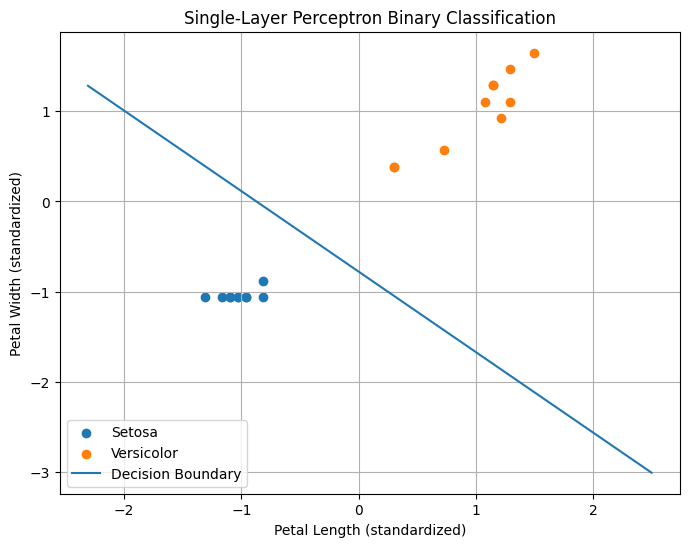

In [35]:
# 7. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print("\nSingle-Layer Perceptron Results")
print("--------------------------------")
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Setosa", "Versicolor"]
))
# Plot the test data
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test[y_test == 0, 0],
    X_test[y_test == 0, 1],
    label="Setosa"
)

plt.scatter(
    X_test[y_test == 1, 0],
    X_test[y_test == 1, 1],
    label="Versicolor"
)

# Decision boundary
w = model.coef_[0]
b = model.intercept_[0]

x_values = np.linspace(
    X_test[:, 0].min() - 1,
    X_test[:, 0].max() + 1,
    100
)

y_values = -(w[0] * x_values + b) / w[1]

plt.plot(
    x_values,
    y_values,
    label="Decision Boundary"
)

plt.xlabel("Petal Length (standardized)")
plt.ylabel("Petal Width (standardized)")
plt.title("Single-Layer Perceptron Binary Classification")
plt.legend()
plt.grid(True)
plt.show()

Comparision Between Single Layer Perceptron(SLP) and Multi-Layer Perceptron(MLP)

All feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Features used: ['petal length (cm)', 'petal width (cm)']
Dataset shape: (100, 2)
Classes: [0 1] -> 0: Setosa, 1: Versicolor

================ Single-Layer Perceptron ================
Accuracy: 1.0

Confusion Matrix:
[[10  0]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


================ Multi-Layer Perceptron ================
Accuracy: 1.0

Confusion Matrix:
[[10  0]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10

    accuracy 

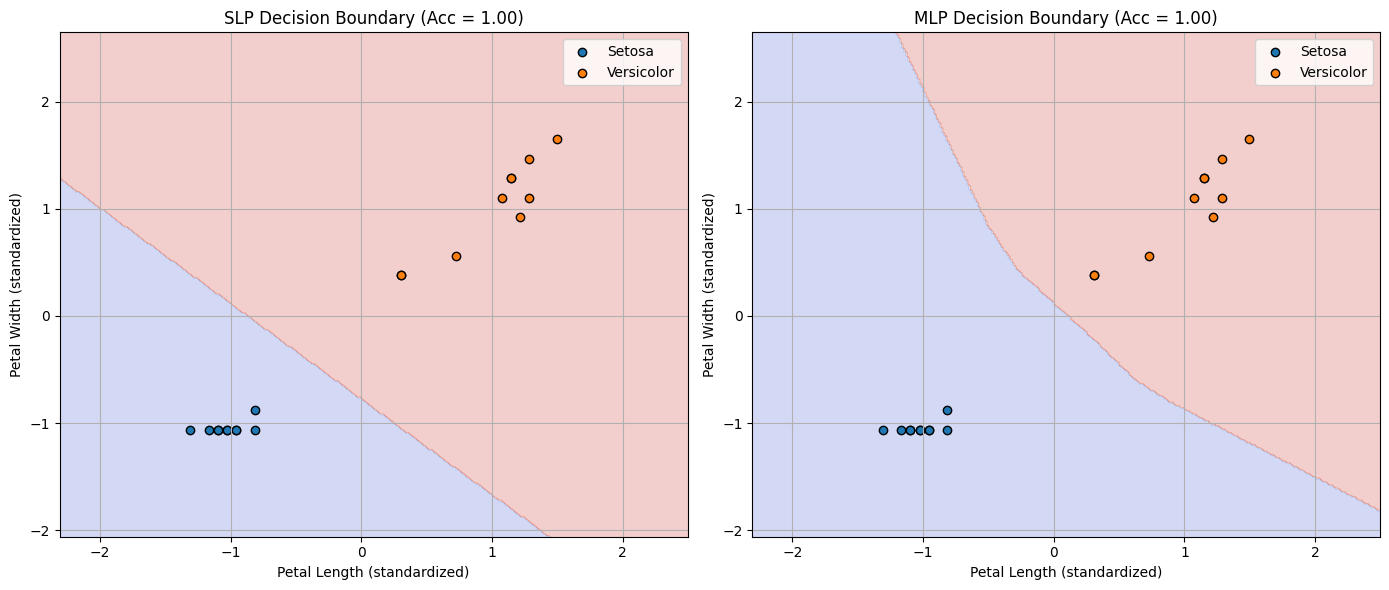


Plot saved as 'slp_vs_mlp_decision_boundaries.png'


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load Iris dataset and create binary classification set

iris = load_iris()
print("All feature names:", iris.feature_names)

# Use only Setosa (0) and Versicolor (1) -> first 100 samples
# Use Petal length & Petal width (columns 2, 3) for easy 2D visualization
X = iris.data[:100, [2, 3]]
y = iris.target[:100]

features_used = [iris.feature_names[i] for i in [2, 3]]
print("\nFeatures used:", features_used)
print("Dataset shape:", X.shape)
print("Classes:", np.unique(y), "-> 0: Setosa, 1: Versicolor")


# 2. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Feature scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# PART A: SINGLE-LAYER PERCEPTRON (SLP)

slp_model = Perceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)
slp_model.fit(X_train, y_train)
y_pred_slp = slp_model.predict(X_test)

slp_accuracy = accuracy_score(y_test, y_pred_slp)

print("\n================ Single-Layer Perceptron ================")
print("Accuracy:", slp_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_slp))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_slp, target_names=["Setosa", "Versicolor"]))

# PART B: MULTI-LAYER PERCEPTRON (MLP)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(8, 4),   # 2 hidden layers: 8 and 4 neurons
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

print("\n================ Multi-Layer Perceptron ================")
print("Accuracy:", mlp_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_mlp))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=["Setosa", "Versicolor"]))

# ===========================================================
# PART C: SIDE-BY-SIDE COMPARISON SUMMARY
# ===========================================================
print("\n================ Comparison Summary ================")
print(f"{'Model':<25}{'Accuracy':<10}")
print(f"{'Single-Layer Perceptron':<25}{slp_accuracy:<10.4f}")
print(f"{'Multi-Layer Perceptron':<25}{mlp_accuracy:<10.4f}")

print("""
Parameter                          SLP                 MLP
--------------------------------------------------------------
Hidden layers                      0                   1 or more
Activation                         Step function       ReLU + output activation
Decision boundary                  Linear              Non-linear
Training complexity                Low                 Higher
Computational cost                 Low                 Higher
Ability to learn complex patterns  Limited             Better
Binary classification              Yes                 Yes
""")

# PART D: VISUALIZATION - DECISION BOUNDARIES SIDE BY SIDE

def plot_decision_boundary(ax, model, X_set, y_set, title):
    x_min, x_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
    y_min, y_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)
    ax.scatter(
        X_set[y_set == 0, 0], X_set[y_set == 0, 1],
        label="Setosa", edgecolor='k'
    )
    ax.scatter(
        X_set[y_set == 1, 0], X_set[y_set == 1, 1],
        label="Versicolor", edgecolor='k'
    )
    ax.set_xlabel("Petal Length (standardized)")
    ax.set_ylabel("Petal Width (standardized)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(
    axes[0], slp_model, X_test, y_test,
    f"SLP Decision Boundary (Acc = {slp_accuracy:.2f})"
)
plot_decision_boundary(
    axes[1], mlp_model, X_test, y_test,
    f"MLP Decision Boundary (Acc = {mlp_accuracy:.2f})"
)

plt.tight_layout()
plt.savefig("slp_vs_mlp_decision_boundaries.png", dpi=150)
plt.show()

print("\nPlot saved as 'slp_vs_mlp_decision_boundaries.png'")